3. Linear regression with multiple variables


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("G:\\My Drive\\ML\\ex1data2.txt",header=None)
df.columns=["Size","Bedrooms","Price"]
df.head()

,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


3.1 Feature Normalizatio

In [12]:
X=np.c_[df["Size"].values,df["Bedrooms"].values]
Y=df["Price"].values
m=len(Y)


In [15]:
Y=Y.reshape(m,1)

In [16]:
Y

array([[399900],
       [329900],
       [369000],
       [232000],
       [539900],
       [299900],
       [314900],
       [198999],
       [212000],
       [242500],
       [239999],
       [347000],
       [329999],
       [699900],
       [259900],
       [449900],
       [299900],
       [199900],
       [499998],
       [599000],
       [252900],
       [255000],
       [242900],
       [259900],
       [573900],
       [249900],
       [464500],
       [469000],
       [475000],
       [299900],
       [349900],
       [169900],
       [314900],
       [579900],
       [285900],
       [249900],
       [229900],
       [345000],
       [549000],
       [287000],
       [368500],
       [329900],
       [314000],
       [299000],
       [179900],
       [299900],
       [239500]])

In [17]:
def feature_normalize(X):
    X_mean=np.mean(X,axis=0)
    X_std=np.std(X,axis=0,ddof=0)
    X_norm=(X-X_mean)/X_std
    return X_norm,X_mean,X_std

In [18]:
X_norm,X_mean,X_std=feature_normalize(X)

In [19]:
X_norm.shape

(47, 2)

In [20]:
X_norm[:5]

array([[ 0.13141542, -0.22609337],
       [-0.5096407 , -0.22609337],
       [ 0.5079087 , -0.22609337],
       [-0.74367706, -1.5543919 ],
       [ 1.27107075,  1.10220517]])

In [21]:
m=len(Y)
X_norm=np.c_[np.ones(m),X_norm]
X_norm.shape

(47, 3)

In [22]:
X_norm[:5]

array([[ 1.        ,  0.13141542, -0.22609337],
       [ 1.        , -0.5096407 , -0.22609337],
       [ 1.        ,  0.5079087 , -0.22609337],
       [ 1.        , -0.74367706, -1.5543919 ],
       [ 1.        ,  1.27107075,  1.10220517]])

In [23]:

Y.shape

(47, 1)

In [24]:
# 0o 01 02 values 
theta=np.zeros((3,1)) 
theta 

array([[0.],
       [0.],
       [0.]])

In [25]:
def cost_function(X_norm,Y,theta):
    m=len(Y)
    predictions=X_norm @ theta  #h0(x)
    errors=predictions-Y
    cost=(1/(2*m))*np.sum(errors**2)
    return cost


In [26]:
initial_cost=cost_function(X_norm,Y,theta)

In [27]:
initial_cost

np.float64(65591548106.45744)

In [28]:
print((1/(2*m))*np.sum(Y**2))

65591548106.45744


3.2 Gradient Descent

In [29]:
def gradient_descent(X,Y,theta,alpha,iterations):
    m=len(Y)
    J_history=[]

    for _ in range(iterations):
        predictions=X @ theta
        errors=predictions-Y
        theta=theta-(alpha/m)*(X.T @ errors)
        J_history.append(cost_function(X,Y,theta))

    return theta,J_history

In [55]:
alpha=0.1
iterations=50

theta,J_history=gradient_descent(X_norm,Y,theta,alpha,iterations)
print(theta)

[[340403.61773803]
 [108803.37852266]
 [ -5933.9413402 ]]


In [65]:
## Predictiong our model
X_new=pd.Series({"size": 1650 ,"bedroom":3})
X_new_norm=(X_new - X_mean)/X_std
X_new_aug=np.r_[1,X_new_norm.values]

price=X_new_aug @ theta
print(price)

[293214.16354571]


Graph for Gradient Descent

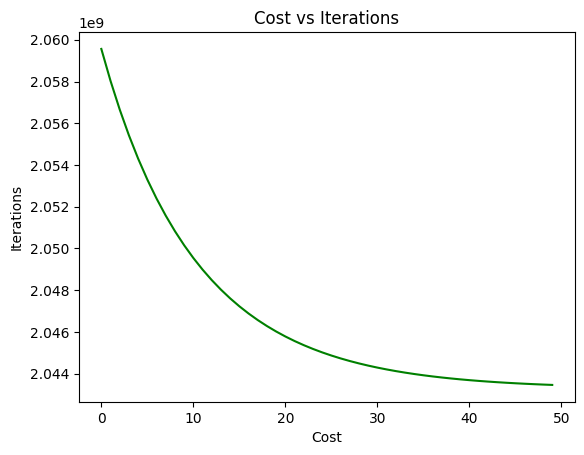

In [56]:
plt.plot(J_history,c="green")
plt.xlabel("Cost")
plt.ylabel("Iterations")
plt.title("Cost vs Iterations")
plt.show()

In [57]:
alpha1=0.01
alpha2=0.001
alpha3=1

iterations=50

theta1,J_history1=gradient_descent(X_norm,Y,theta,alpha1,iterations)
print(theta1)

theta2,J_history2=gradient_descent(X_norm,Y,theta,alpha2,iterations)
print(theta2)

theta3,J_history3=gradient_descent(X_norm,Y,theta,alpha3,iterations)
print(theta3)

[[340407.18920857]
 [108930.899215  ]
 [ -6061.45961922]]
[[340404.05892876]
 [108817.40511007]
 [ -5947.96759473]]
[[340412.65957447]
 [109447.79646964]
 [ -6578.35485416]]


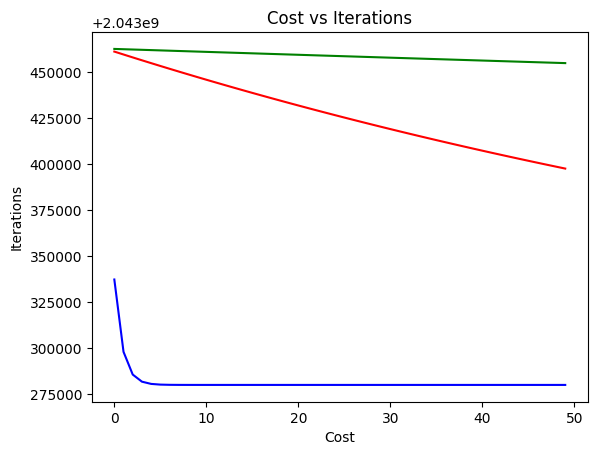

In [58]:
plt.plot(J_history1,c="red")
plt.plot(J_history2,c="green")
plt.plot(J_history3,c="blue")
plt.xlabel("Cost")
plt.ylabel("Iterations")
plt.title("Cost vs Iterations")
plt.show()

3.3 Normal Equations

In [59]:
X_ne=np.c_[np.ones(m),X]

In [60]:
print(X_ne.shape)
print(Y.shape)

(47, 3)
(47, 1)


In [61]:
theta_nr=np.linalg.pinv(X_ne.T @ X_ne) @ X_ne.T @ Y
print(theta_nr)

[[89597.90954355]
 [  139.21067402]
 [-8738.01911255]]


In [67]:
x_new = np.array([1, 1650, 3])
price_ne = x_new @ theta_nr
print(price_ne)

[293081.46433497]
